# RootList Sequence Predictor

This notebook implements a Transformer-based sequence prediction model that:
1. Uses **full graph** GCN embeddings (all nodes, all edges) for rich representations
2. Trains sequence prediction only on **wNum=0 leaf nodes** with complete RootLists
3. Uses a context window of 8 prior nodes
4. Autoregressively predicts the next RootList (size + contents)

**Architecture**: The GCN/GAT sees the full graph structure (all wNum levels), which
allows it to learn better embeddings for leaf nodes by leveraging parent-child relationships.
The sequence prediction task then operates on the wNum=0 subset.

**Key insight**: The generator guarantees one root at a known position, but additional roots
emerge from the mathematical structure. Predicting both size and contents tests whether
the model learns the underlying mathematics.

## 1. Setup and Configuration

In [1]:
import os
import sys
from pathlib import Path
from typing import List, Tuple, Optional, Dict
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.data import Data

from sklearn.model_selection import train_test_split
from dotenv import load_dotenv

# Add parent directories to path
project_root = Path.cwd().parent.parent.parent
ml_pipeline_root = Path.cwd().parent  # For python_model imports
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(ml_pipeline_root))  # Add path for python_model
sys.path.insert(0, str(project_root / 'ml' / 'neo4j'))

from neo4jClient import Neo4jClient

# Load environment variables - search multiple locations
env_paths = [Path('.env'), Path('../.env'), Path('../../.env'), Path('../../../.env')]

for env_path in env_paths:
    if env_path.exists():
        load_dotenv(env_path, override=True)
        print(f"✓ Loaded .env from: {env_path.absolute()}")
        break
else:
    print("⚠ Warning: No .env file found")

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

✓ Loaded .env from: c:\Users\tomas\JavaProjects\Aibeceles\ml\graph_label_prediction\workbooks\..\..\.env

PyTorch version: 2.9.1+cpu
CUDA available: False
Using device: cpu


In [2]:
# =============================================================================
# Configuration
# =============================================================================

@dataclass
class SequencePredictorConfig:
    """Configuration for the RootList sequence predictor."""
    
    # Data settings
    context_window_size: int = 8  # Number of prior nodes for context
    
    # Vocabulary settings
    min_root_value: int = -82  # Minimum integer in RootList (expanded to cover actual data)
    max_root_value: int = 49   # Maximum integer in RootList (expanded to cover actual data)
    max_rootlist_size: int = 5  # Maximum size of RootList (increased to handle actual data)
    
    # Model settings
    encoder_type: str = 'gcn'  # 'gcn' or 'gat'
    hidden_dim: int = 64
    num_encoder_layers: int = 2
    num_decoder_layers: int = 2
    num_attention_heads: int = 4
    dropout: float = 0.1
    
    # Node features (match existing pipeline)
    num_node_features: int = 16  # wNum + degree + determined + coeffs + stats + set_union
    
    # Training settings
    learning_rate: float = 0.001
    weight_decay: float = 1e-4
    batch_size: int = 32
    max_epochs: int = 100
    patience: int = 10
    
    # Random seed
    random_seed: int = 42
    
    @property
    def vocab_size(self) -> int:
        """Total vocabulary size: integers + special tokens."""
        # Integers from min_root_value to max_root_value
        num_integers = self.max_root_value - self.min_root_value + 1  # 41
        # Special tokens: SOS, PAD
        num_special = 2
        return num_integers + num_special  # 43
    
    @property
    def sos_token_id(self) -> int:
        """Start-of-sequence token ID."""
        return self.max_root_value - self.min_root_value + 1  # 41
    
    @property
    def pad_token_id(self) -> int:
        """Padding token ID."""
        return self.max_root_value - self.min_root_value + 2  # 42


config = SequencePredictorConfig()
print(f"Configuration:")
print(f"  Context window: {config.context_window_size}")
print(f"  Vocabulary size: {config.vocab_size}")
print(f"  SOS token ID: {config.sos_token_id}")
print(f"  PAD token ID: {config.pad_token_id}")

Configuration:
  Context window: 8
  Vocabulary size: 134
  SOS token ID: 132
  PAD token ID: 133


## 2. Data Loading and Sequence Construction

In [3]:
# =============================================================================
# Neo4j Queries (imported from config.py)
# =============================================================================

# Import queries from shared config
from python_model.core.config import (
    get_node_query,
    get_edge_query,
    get_sequence_node_query,
    USE_GRAPH_FILTERING,
)

# Get queries based on filtering configuration
# ALL_NODES_QUERY: Full graph for GCN embeddings (same query CORAL uses)
# EDGE_QUERY: All zMap edges for GCN
# SEQUENCE_NODE_QUERY: wNum=0 nodes with complete RootLists for sequence training
ALL_NODES_QUERY = get_node_query(USE_GRAPH_FILTERING)
EDGE_QUERY = get_edge_query(USE_GRAPH_FILTERING)
SEQUENCE_NODE_QUERY = get_sequence_node_query(USE_GRAPH_FILTERING)

filtering_status = "enabled" if USE_GRAPH_FILTERING else "disabled"
print(f"Queries loaded from config.py (pArray filtering={filtering_status})")
print(f"  - ALL_NODES_QUERY: Full graph for GCN embeddings")
print(f"  - EDGE_QUERY: All zMap edges")
print(f"  - SEQUENCE_NODE_QUERY: wNum=0 nodes for sequence training")

Queries loaded from config.py (pArray filtering=enabled)
  - ALL_NODES_QUERY: Full graph for GCN embeddings
  - EDGE_QUERY: All zMap edges
  - SEQUENCE_NODE_QUERY: wNum=0 nodes for sequence training


In [4]:
# =============================================================================
# Coefficient Feature Extraction (from existing pipeline)
# =============================================================================

def parse_vm_result(vm_result: str, max_degree: int = 4) -> Tuple[np.ndarray, float, np.ndarray]:
    """
    Parse vmResult string into coefficient features.
    
    Args:
        vm_result: String like "[1, 2, 3, 4, 5]" or list
        max_degree: Maximum polynomial degree (for padding)
        
    Returns:
        Tuple of (coefficients, degree, statistics)
    """
    if vm_result is None:
        coeffs = np.zeros(max_degree + 1, dtype=np.float32)
        return coeffs, 0.0, np.zeros(5, dtype=np.float32)
    
    # Parse coefficients
    if isinstance(vm_result, str):
        # Remove brackets and split
        vm_result = vm_result.strip('[]')
        if not vm_result:
            coeffs_list = []
        else:
            coeffs_list = [float(x.strip()) for x in vm_result.split(',')]
    elif isinstance(vm_result, list):
        coeffs_list = [float(x) for x in vm_result]
    else:
        coeffs_list = []
    
    # Pad or truncate to max_degree + 1 coefficients
    coeffs = np.zeros(max_degree + 1, dtype=np.float32)
    for i, c in enumerate(coeffs_list[:max_degree + 1]):
        coeffs[i] = c
    
    # Compute degree (position of last non-zero coefficient)
    non_zero_indices = np.nonzero(coeffs_list)[0] if len(coeffs_list) > 0 else []
    degree = float(max(non_zero_indices)) if len(non_zero_indices) > 0 else 0.0
    
    # Compute statistics
    if len(coeffs_list) > 0:
        arr = np.array(coeffs_list, dtype=np.float32)
        magnitude = np.sqrt(np.sum(arr ** 2))
        leading_coeff = np.abs(arr[-1]) if len(arr) > 0 else 0.0
        constant_term = np.abs(arr[0]) if len(arr) > 0 else 0.0
        sparsity = np.sum(arr != 0) / len(arr) if len(arr) > 0 else 0.0
        mean_abs = np.mean(np.abs(arr))
    else:
        magnitude = leading_coeff = constant_term = sparsity = mean_abs = 0.0
    
    stats = np.array([magnitude, leading_coeff, constant_term, sparsity, mean_abs], dtype=np.float32)
    
    return coeffs, degree, stats


print("Feature extraction functions defined.")

Feature extraction functions defined.


In [5]:
# =============================================================================
# SequenceDataLoader
# =============================================================================

class SequenceDataLoader:
    """
    Loads data from Neo4j for RootList sequence prediction.
    
    Uses FULL GRAPH for GCN embeddings (all nodes, all edges) but only
    trains sequence prediction on wNum=0 nodes with complete RootLists.
    
    This allows the GCN to learn from the full graph structure while
    the sequence task focuses on the leaf nodes.
    """
    
    def __init__(
        self,
        client: Neo4jClient,
        database: str,
        config: SequencePredictorConfig,
    ):
        self.client = client
        self.database = database
        self.config = config
        
        # Node ID mappings (for FULL graph)
        self._node_id_to_idx: Dict[str, int] = {}
        self._idx_to_node_id: Dict[int, str] = {}
        
        # Data storage (FULL graph for GCN)
        self.all_nodes_df = None       # All nodes in graph
        self.edges_df = None
        self.node_features = None      # [num_all_nodes, num_features]
        self.edge_index = None         # [2, num_edges]
        
        # Sequence-specific data (wNum=0 subset)
        self.seq_nodes_df = None       # Only wNum=0 nodes with complete RootLists
        self.sequence_node_indices = None  # Global indices of sequence nodes
        self.root_lists = None         # RootList for each sequence node
    
    def load(self) -> 'SequenceDataLoader':
        """
        Load data from Neo4j.
        
        1. Loads ALL nodes for GCN embeddings (full graph)
        2. Loads ALL edges for GCN (full graph)
        3. Loads wNum=0 nodes with complete RootLists for sequence training
        
        Returns:
            Self for method chaining.
        """
        # Step 1: Load ALL nodes for GCN
        print("Loading ALL nodes from Neo4j (full graph for GCN embeddings)...")
        self.all_nodes_df = self.client.run_query(ALL_NODES_QUERY, self.database)
        print(f"  Loaded {len(self.all_nodes_df)} total nodes")
        
        if len(self.all_nodes_df) == 0:
            raise ValueError("No nodes found in database")
        
        # Build global node ID mapping
        self._node_id_to_idx = {
            node_id: idx for idx, node_id in enumerate(self.all_nodes_df['node_id'])
        }
        self._idx_to_node_id = {
            idx: node_id for node_id, idx in self._node_id_to_idx.items()
        }
        
        # Build node features for ALL nodes
        self._build_node_features()
        
        # Step 2: Load ALL edges
        print("Loading ALL edges from Neo4j (full graph for GCN)...")
        self.edges_df = self.client.run_query(EDGE_QUERY, self.database)
        self._build_edge_index()
        print(f"  Loaded {self.edge_index.shape[1]} edges (undirected)")
        
        # Step 3: Load wNum=0 sequence nodes
        print("Loading wNum=0 nodes for sequence prediction...")
        self.seq_nodes_df = self.client.run_query(SEQUENCE_NODE_QUERY, self.database)
        print(f"  Loaded {len(self.seq_nodes_df)} leaf nodes with complete RootLists")
        
        if len(self.seq_nodes_df) == 0:
            raise ValueError("No wNum=0 nodes with complete RootLists found")
        
        # Map sequence node IDs to global indices
        self._build_sequence_mappings()
        
        # Extract RootLists for sequence nodes
        self._extract_root_lists()
        
        return self
    
    def _build_node_features(self):
        """
        Build 16D node feature matrix for ALL nodes.
        
        Features: [wNum, degree, determined, coeffs[5], stats[5], n, mu_d, mu_ratio]
        """
        num_nodes = len(self.all_nodes_df)
        features = np.zeros((num_nodes, self.config.num_node_features), dtype=np.float32)
        
        for i, (_, row) in enumerate(self.all_nodes_df.iterrows()):
            # wNum (now varies across all nodes)
            features[i, 0] = float(row.get('wNum', 0) or 0)
            
            # Parse vmResult for degree and coefficients
            coeffs, degree, stats = parse_vm_result(row.get('vmResult'))
            features[i, 1] = degree
            
            # Determined flag
            features[i, 2] = float(row.get('determined', 0) or 0)
            
            # Coefficients (5D)
            features[i, 3:8] = coeffs
            
            # Statistics (5D)
            features[i, 8:13] = stats
            
            # Set union ratio features
            n_val = float(row.get('n', 0) or 0)
            mu_d_val = float(row.get('mu_d', 0) or 0)
            mu_ratio = n_val / mu_d_val if mu_d_val > 0 else 0.0
            features[i, 13] = n_val
            features[i, 14] = mu_d_val
            features[i, 15] = mu_ratio
        
        self.node_features = torch.tensor(features, dtype=torch.float32)
        print(f"  Built feature matrix for full graph: {self.node_features.shape}")
        
        # Report wNum distribution
        #wnum_counts = self.all_nodes_df['wNum'].value_counts().sort_index()
        #print(f"  wNum distribution: {dict(wnum_counts)}")
    
    def _build_sequence_mappings(self):
        """
        Create mapping from sequence node IDs to global indices.
        
        sequence_node_indices[seq_idx] = global_idx
        """
        self.sequence_node_indices = []
        missing_count = 0
        
        for node_id in self.seq_nodes_df['node_id']:
            global_idx = self._node_id_to_idx.get(node_id)
            if global_idx is not None:
                self.sequence_node_indices.append(global_idx)
            else:
                missing_count += 1
        
        if missing_count > 0:
            print(f"  Warning: {missing_count} sequence nodes not found in full graph")
        
        print(f"  Mapped {len(self.sequence_node_indices)} sequence nodes to global indices")
    
    def _extract_root_lists(self):
        """
        Extract RootList for each sequence node (wNum=0 only).
        """
        self.root_lists = []
        for _, row in self.seq_nodes_df.iterrows():
            root_list = row.get('RootList', [])
            if root_list is None:
                root_list = []
            elif isinstance(root_list, str):
                # Parse string representation
                root_list = root_list.strip('[]')
                if root_list:
                    root_list = [int(x.strip()) for x in root_list.split(',')]
                else:
                    root_list = []
            self.root_lists.append(list(root_list))
        
        # Statistics
        sizes = [len(rl) for rl in self.root_lists]
        print(f"  RootList size distribution: min={min(sizes)}, max={max(sizes)}, mean={np.mean(sizes):.2f}")
    
    def _build_edge_index(self):
        """
        Build edge index tensor for FULL graph (undirected: add both directions).
        """
        if len(self.edges_df) == 0:
            self.edge_index = torch.zeros((2, 0), dtype=torch.long)
            return
        
        edge_list = []
        edges_found = 0
        edges_missing = 0
        
        for _, row in self.edges_df.iterrows():
            src_idx = self._node_id_to_idx.get(row['source'])
            tgt_idx = self._node_id_to_idx.get(row['target'])
            
            if src_idx is not None and tgt_idx is not None:
                # Add both directions for undirected graph
                edge_list.append([src_idx, tgt_idx])
                edge_list.append([tgt_idx, src_idx])
                edges_found += 1
            else:
                edges_missing += 1
        
        if edges_missing > 0:
            print(f"  Warning: {edges_missing} edges reference nodes not in graph")
        
        if edge_list:
            self.edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
        else:
            self.edge_index = torch.zeros((2, 0), dtype=torch.long)
    
    def create_sequence_dataset(
        self,
        train_ratio: float = 0.7,
        val_ratio: float = 0.15,
        test_ratio: float = 0.15,
    ) -> Tuple['SequenceDataset', 'SequenceDataset', 'SequenceDataset']:
        """
        Create train/val/test SequenceDataset objects.
        
        Uses sliding window over wNum=0 sequence nodes to create 
        (context, target) pairs. Context indices are GLOBAL indices
        into the full graph (for GCN embeddings).
        
        Returns:
            Tuple of (train_dataset, val_dataset, test_dataset)
        """
        num_seq_nodes = len(self.sequence_node_indices)
        window_size = self.config.context_window_size
        
        # Create sliding window samples using GLOBAL indices
        # Each sample: 
        #   context_global_indices = [sequence_node_indices[i], ..., sequence_node_indices[i+window_size-1]]
        #   target_seq_idx = i + window_size (index into root_lists)
        samples = []
        for i in range(num_seq_nodes - window_size):
            # Context: global indices for GCN embedding lookup
            context_global_indices = [
                self.sequence_node_indices[j] for j in range(i, i + window_size)
            ]
            # Target: sequence-local index for RootList lookup
            target_seq_idx = i + window_size
            samples.append((context_global_indices, target_seq_idx))
        
        print(f"Created {len(samples)} sequence samples (window size = {window_size})")
        print(f"  Using {num_seq_nodes} wNum=0 nodes from full graph of {len(self.node_features)} nodes")
        
        # Split samples
        np.random.seed(self.config.random_seed)
        indices = np.arange(len(samples))
        np.random.shuffle(indices)
        
        n_train = int(len(samples) * train_ratio)
        n_val = int(len(samples) * val_ratio)
        
        train_indices = indices[:n_train]
        val_indices = indices[n_train:n_train + n_val]
        test_indices = indices[n_train + n_val:]
        
        train_samples = [samples[i] for i in train_indices]
        val_samples = [samples[i] for i in val_indices]
        test_samples = [samples[i] for i in test_indices]
        
        print(f"Split: train={len(train_samples)}, val={len(val_samples)}, test={len(test_samples)}")
        
        # Create datasets - pass full graph data
        train_dataset = SequenceDataset(
            samples=train_samples,
            node_features=self.node_features,  # Full graph features
            root_lists=self.root_lists,        # Only wNum=0 RootLists
            edge_index=self.edge_index,        # Full graph edges
            config=self.config,
        )
        val_dataset = SequenceDataset(
            samples=val_samples,
            node_features=self.node_features,
            root_lists=self.root_lists,
            edge_index=self.edge_index,
            config=self.config,
        )
        test_dataset = SequenceDataset(
            samples=test_samples,
            node_features=self.node_features,
            root_lists=self.root_lists,
            edge_index=self.edge_index,
            config=self.config,
        )
        
        return train_dataset, val_dataset, test_dataset
    
    def get_pyg_data(self) -> Data:
        """
        Get PyTorch Geometric Data object for GCN encoding.
        
        Returns FULL graph data for computing embeddings.
        """
        return Data(
            x=self.node_features,
            edge_index=self.edge_index,
        )


print("SequenceDataLoader defined (full graph for embeddings, wNum=0 for sequence).")

SequenceDataLoader defined (full graph for embeddings, wNum=0 for sequence).


In [6]:
# =============================================================================
# SequenceDataset
# =============================================================================

class SequenceDataset(Dataset):
    """
    PyTorch Dataset for sequence prediction.
    
    Uses FULL GRAPH embeddings but only trains on wNum=0 sequence nodes.
    
    Each sample contains:
    - context_indices: GLOBAL indices into full graph [window_size]
                       (used to look up embeddings from GCN output)
    - target_root_list: Tokenized target RootList [max_len]
    - target_size: Size of the target RootList (totalZero)
    
    Note: context_indices are global indices into node_features (full graph).
          target_idx is a sequence-local index into root_lists (wNum=0 only).
    """
    
    def __init__(
        self,
        samples: List[Tuple[List[int], int]],
        node_features: torch.Tensor,
        root_lists: List[List[int]],
        edge_index: torch.Tensor,
        config: SequencePredictorConfig,
    ):
        self.samples = samples
        self.node_features = node_features  # Full graph features
        self.root_lists = root_lists        # Only wNum=0 RootLists
        self.edge_index = edge_index        # Full graph edges
        self.config = config
    
    def __len__(self) -> int:
        return len(self.samples)
    
    def root_to_token(self, root_value: int) -> int:
        """
        Convert root integer value to token ID.
        
        Maps [-20, 20] to [0, 40].
        """
        return root_value - self.config.min_root_value
    
    def token_to_root(self, token_id: int) -> int:
        """
        Convert token ID back to root integer value.
        """
        return token_id + self.config.min_root_value
    
    def tokenize_root_list(self, root_list: List[int]) -> torch.Tensor:
        """
        Tokenize a RootList into target sequence.
        
        Format: [size, r1, r2, ..., rk, PAD, PAD, ...]
        where size is treated as first token (1-4 mapped to 0-3 in size vocab)
        
        Returns:
            Token tensor of shape [max_rootlist_size + 1] (size + elements)
        """
        max_len = self.config.max_rootlist_size + 1  # +1 for size token
        tokens = torch.full((max_len,), self.config.pad_token_id, dtype=torch.long)
        
        # First token is size (as 0-indexed: size-1 if size > 0, else 0)
        size = len(root_list)
        tokens[0] = size  # Size directly as token (will use separate head or embedding)
        
        # Remaining tokens are root values
        for i, root in enumerate(root_list[:self.config.max_rootlist_size]):
            tokens[i + 1] = self.root_to_token(root)
        
        return tokens
    
    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        """
        Get a single sample.
        
        Returns:
            Dictionary with:
            - context_indices: [window_size] GLOBAL node indices for context
                               (indexes into full graph embeddings from GCN)
            - target_tokens: [max_len] tokenized target RootList
            - target_size: scalar, size of target RootList
            - target_mask: [max_len] mask for valid positions (not PAD)
        """
        context_global_indices, target_seq_idx = self.samples[idx]
        
        # Get target RootList (using sequence-local index)
        target_root_list = self.root_lists[target_seq_idx]
        target_tokens = self.tokenize_root_list(target_root_list)
        target_size = len(target_root_list)
        
        # Create mask for valid positions
        target_mask = torch.zeros(self.config.max_rootlist_size + 1, dtype=torch.bool)
        target_mask[:target_size + 1] = True  # +1 for size token
        
        return {
            # Global indices for full graph embedding lookup
            'context_indices': torch.tensor(context_global_indices, dtype=torch.long),
            'target_tokens': target_tokens,
            'target_size': torch.tensor(target_size, dtype=torch.long),
            'target_mask': target_mask,
        }


print("SequenceDataset defined (uses global indices for full graph embeddings).")

SequenceDataset defined (uses global indices for full graph embeddings).


## 3. Load Data from Neo4j

In [7]:
# Get Neo4j connection parameters
NEO4J_URI = os.getenv('NEO4J_URI', 'bolt://localhost:7687')
NEO4J_USER = os.getenv('NEO4J_USER', 'neo4j')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
NEO4J_DATABASE = os.getenv('NEO4J_DATABASE', 'd4seed1')

print("Connection Configuration:")
print(f"  URI: {NEO4J_URI}")
print(f"  User: {NEO4J_USER}")
print(f"  Password: {'*' * len(NEO4J_PASSWORD) if NEO4J_PASSWORD else 'NOT SET'}")
print(f"  Database: {NEO4J_DATABASE}")

if not NEO4J_PASSWORD:
    raise ValueError("NEO4J_PASSWORD not set in environment variables")

print(f"\nConnecting to Neo4j...")
client = Neo4jClient(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD)

# Load data
loader = SequenceDataLoader(client, NEO4J_DATABASE, config)
loader.load()

# Create datasets
train_dataset, val_dataset, test_dataset = loader.create_sequence_dataset()

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False)

print(f"\nData loaders created:")
print(f"  Train: {len(train_loader)} batches")
print(f"  Val: {len(val_loader)} batches")
print(f"  Test: {len(test_loader)} batches")

Connection Configuration:
  URI: bolt://localhost:7687
  User: neo4j
  Password: ***********
  Database: d5seed1

Connecting to Neo4j...
Loading ALL nodes from Neo4j (full graph for GCN embeddings)...


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }', position=<SummaryInputPosition line=4, column=1, offset=29>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 29, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (dd:Dnode)   \nWITH dd\nCALL {\n     WITH dd\n     MATCH (dd)-[:CreatedBye]->(cb)   // and constrain d against all pArrays.\n     WHERE all(x IN cb.pArrayList WHERE x >= 0 AND x < 10 )\n     //WHERE ( all(x IN 

  Loaded 54484 total nodes
  Built feature matrix for full graph: torch.Size([54484, 16])
Loading ALL edges from Neo4j (full graph for GCN)...


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }', position=<SummaryInputPosition line=4, column=1, offset=24>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 24, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (d:Dnode)\nWITH d\nCALL {\n     WITH d\n     MATCH (d)-[:CreatedBye]->(cb)   // and constrain d against all pArrays.\n     WHERE all(x IN cb.pArrayList WHERE x >= 0 AND x < 10)\n     //WHERE ( all(x IN cb.pArrayL

  Loaded 108966 edges (undirected)
Loading wNum=0 nodes for sequence prediction...


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }', position=<SummaryInputPosition line=14, column=1, offset=397>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 397, 'line': 14, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n//MATCH (d:Dnode)-[:CreatedBye]->(cb:CreatedBy {wNum:0})\n//WHERE size(d.RootList) = d.totalZero\n//  AND all(x IN cb.pArrayList WHERE x >= 0 AND x < 7)\n//WITH DISTINCT d \n//RETURN elementId(d) as node_id,\n// 

  Loaded 182508 leaf nodes with complete RootLists
  Mapped 182508 sequence nodes to global indices
  RootList size distribution: min=1, max=5, mean=1.53
Created 182500 sequence samples (window size = 8)
  Using 182508 wNum=0 nodes from full graph of 54484 nodes
Split: train=127749, val=27375, test=27376

Data loaders created:
  Train: 3993 batches
  Val: 856 batches
  Test: 856 batches


## 4. Vocabulary and Tokenization

In [8]:
# =============================================================================
# RootListTokenizer
# =============================================================================

class RootListTokenizer:
    """
    Tokenizer for RootList sequences.
    
    Vocabulary:
    - Tokens 0-40: integers -20 to +20
    - Token 41: SOS (start of sequence)
    - Token 42: PAD (padding)
    
    Size is handled separately (1-4 mapped to dedicated tokens or embedding).
    """
    
    def __init__(self, config: SequencePredictorConfig):
        self.config = config
        self.min_val = config.min_root_value
        self.max_val = config.max_root_value
        
        # Special token IDs
        self.sos_id = config.sos_token_id
        self.pad_id = config.pad_token_id
        self.vocab_size = config.vocab_size
    
    def encode_root(self, value: int) -> int:
        """Convert root integer to token ID."""
        return value - self.min_val
    
    def decode_root(self, token_id: int) -> int:
        """Convert token ID to root integer."""
        return token_id + self.min_val
    
    def encode_sequence(self, root_list: List[int], add_sos: bool = True) -> torch.Tensor:
        """
        Encode a RootList into token IDs.
        
        Args:
            root_list: List of integer roots
            add_sos: Whether to prepend SOS token
            
        Returns:
            Token tensor
        """
        tokens = []
        if add_sos:
            tokens.append(self.sos_id)
        
        for root in root_list:
            tokens.append(self.encode_root(root))
        
        return torch.tensor(tokens, dtype=torch.long)
    
    def decode_sequence(self, tokens: torch.Tensor) -> List[int]:
        """
        Decode token IDs back to RootList.
        
        Args:
            tokens: Token tensor
            
        Returns:
            List of integer roots (excluding special tokens)
        """
        result = []
        for t in tokens.tolist():
            if t == self.sos_id or t == self.pad_id:
                continue
            if 0 <= t <= (self.max_val - self.min_val):
                result.append(self.decode_root(t))
        return result
    
    def create_decoder_input(self, target_tokens: torch.Tensor) -> torch.Tensor:
        """
        Create decoder input from target tokens (teacher forcing).
        
        Decoder input = [SOS] + target[:-1]
        
        Args:
            target_tokens: Target sequence [batch, seq_len]
            
        Returns:
            Decoder input [batch, seq_len]
        """
        batch_size, seq_len = target_tokens.shape
        decoder_input = torch.full((batch_size, seq_len), self.pad_id, dtype=torch.long, device=target_tokens.device)
        decoder_input[:, 0] = self.sos_id
        decoder_input[:, 1:] = target_tokens[:, :-1]
        return decoder_input


# Create tokenizer
tokenizer = RootListTokenizer(config)

# Test tokenization
test_root_list = [-3, 0, 5, 12]
encoded = tokenizer.encode_sequence(test_root_list)
decoded = tokenizer.decode_sequence(encoded)

print(f"Tokenizer test:")
print(f"  Original: {test_root_list}")
print(f"  Encoded: {encoded.tolist()}")
print(f"  Decoded: {decoded}")
print(f"  Vocab size: {tokenizer.vocab_size}")
print(f"  SOS ID: {tokenizer.sos_id}, PAD ID: {tokenizer.pad_id}")

Tokenizer test:
  Original: [-3, 0, 5, 12]
  Encoded: [132, 79, 82, 87, 94]
  Decoded: [-3, 0, 5, 12]
  Vocab size: 134
  SOS ID: 132, PAD ID: 133


## 5. Model Architecture

In [9]:
# =============================================================================
# Node Encoder (GCN or GAT backbone)
# =============================================================================

class NodeEncoder(nn.Module):
    """
    Graph encoder for node embeddings.
    
    Uses CORAL-style 2-layer GCN by default, with option for DepthAwareGATv2.
    """
    
    def __init__(
        self,
        num_features: int,
        hidden_dim: int,
        encoder_type: str = 'gcn',
        dropout: float = 0.1,
        num_heads: int = 4,
    ):
        super().__init__()
        self.encoder_type = encoder_type
        self.dropout = dropout
        
        if encoder_type == 'gcn':
            # CORAL-style 2-layer GCN
            self.conv1 = GCNConv(num_features, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, hidden_dim)
            self.out_dim = hidden_dim
        elif encoder_type == 'gat':
            # GAT with multiple heads
            self.conv1 = GATConv(num_features, hidden_dim, heads=num_heads, concat=True, dropout=dropout)
            self.conv2 = GATConv(hidden_dim * num_heads, hidden_dim, heads=1, concat=False, dropout=dropout)
            self.out_dim = hidden_dim
        else:
            raise ValueError(f"Unknown encoder type: {encoder_type}")
    
    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        """
        Encode nodes using graph convolutions.
        
        Args:
            x: Node features [num_nodes, num_features]
            edge_index: Edge connectivity [2, num_edges]
            
        Returns:
            Node embeddings [num_nodes, hidden_dim]
        """
        # First layer
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        
        # Second layer
        h = self.conv2(h, edge_index)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        
        return h


print("NodeEncoder defined.")

NodeEncoder defined.


In [10]:
# =============================================================================
# Positional Encoding for Transformer
# =============================================================================

class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding for transformer.
    """
    
    def __init__(self, d_model: int, max_len: int = 100, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        
        self.register_buffer('pe', pe)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Add positional encoding to input.
        
        Args:
            x: Input tensor [batch, seq_len, d_model]
            
        Returns:
            Tensor with positional encoding added [batch, seq_len, d_model]
        """
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


print("PositionalEncoding defined.")

PositionalEncoding defined.


In [11]:
# =============================================================================
# Sequence Encoder (Transformer over node embeddings)
# =============================================================================

class SequenceEncoder(nn.Module):
    """
    Transformer encoder over sequence of node embeddings.
    
    Captures dependencies between context nodes.
    """
    
    def __init__(
        self,
        d_model: int,
        num_layers: int = 2,
        num_heads: int = 4,
        dim_feedforward: int = 256,
        dropout: float = 0.1,
    ):
        super().__init__()
        
        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
    
    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        Encode sequence of node embeddings.
        
        Args:
            x: Node embeddings [batch, seq_len, d_model]
            mask: Optional attention mask
            
        Returns:
            Encoded sequence [batch, seq_len, d_model]
        """
        x = self.pos_encoding(x)
        return self.encoder(x, src_key_padding_mask=mask)


print("SequenceEncoder defined.")

SequenceEncoder defined.


In [12]:
# =============================================================================
# RootList Decoder (Autoregressive Transformer)
# =============================================================================

class RootListDecoder(nn.Module):
    """
    Autoregressive transformer decoder for RootList generation.
    
    - Cross-attention to encoder output (context nodes)
    - Causal self-attention for previously generated tokens
    - Separate heads for size and root predictions
    """
    
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        max_size: int = 4,
        num_layers: int = 2,
        num_heads: int = 4,
        dim_feedforward: int = 256,
        dropout: float = 0.1,
    ):
        super().__init__()
        
        self.d_model = d_model
        self.max_size = max_size
        self.vocab_size = vocab_size
        
        # Token embedding for decoder input
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        
        # Size embedding (for conditioning on predicted/known size)
        self.size_embedding = nn.Embedding(max_size + 1, d_model)  # 0-4 sizes
        
        # Positional encoding
        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)
        
        # Transformer decoder
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        
        # Output heads
        self.size_head = nn.Linear(d_model, max_size + 1)  # Predict size 0-4
        self.root_head = nn.Linear(d_model, vocab_size)    # Predict root tokens
    
    def generate_causal_mask(self, seq_len: int, device: torch.device) -> torch.Tensor:
        """
        Generate causal attention mask for autoregressive decoding.
        
        Returns:
            Upper triangular mask [seq_len, seq_len]
        """
        mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        return mask
    
    def forward(
        self,
        decoder_input: torch.Tensor,
        encoder_output: torch.Tensor,
        tgt_mask: Optional[torch.Tensor] = None,
        memory_mask: Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass for training (teacher forcing).
        
        Args:
            decoder_input: Input tokens [batch, seq_len] (SOS + target[:-1])
            encoder_output: Context embeddings [batch, context_len, d_model]
            tgt_mask: Target attention mask (causal)
            memory_mask: Memory (encoder output) attention mask
            
        Returns:
            Tuple of (size_logits, root_logits)
            - size_logits: [batch, seq_len, max_size+1]
            - root_logits: [batch, seq_len, vocab_size]
        """
        batch_size, seq_len = decoder_input.shape
        
        # Embed tokens
        x = self.token_embedding(decoder_input)  # [batch, seq_len, d_model]
        
        # Add positional encoding
        x = self.pos_encoding(x)
        
        # Generate causal mask if not provided
        if tgt_mask is None:
            tgt_mask = self.generate_causal_mask(seq_len, decoder_input.device)
        
        # Decode
        decoded = self.decoder(
            x,
            encoder_output,
            tgt_mask=tgt_mask,
            memory_key_padding_mask=memory_mask,
        )
        
        # Output heads
        size_logits = self.size_head(decoded)  # [batch, seq_len, max_size+1]
        root_logits = self.root_head(decoded)  # [batch, seq_len, vocab_size]
        
        return size_logits, root_logits


print("RootListDecoder defined.")

RootListDecoder defined.


In [13]:
# =============================================================================
# Full Sequence Predictor Model
# =============================================================================

class SequencePredictor(nn.Module):
    """
    Full model for RootList sequence prediction.
    
    Architecture:
    1. NodeEncoder (GCN/GAT) - embeds all nodes using graph structure
    2. SequenceEncoder (Transformer) - encodes context window of node embeddings
    3. RootListDecoder (Transformer) - autoregressively generates RootList
    """
    
    def __init__(self, config: SequencePredictorConfig):
        super().__init__()
        self.config = config
        
        # Node encoder
        self.node_encoder = NodeEncoder(
            num_features=config.num_node_features,
            hidden_dim=config.hidden_dim,
            encoder_type=config.encoder_type,
            dropout=config.dropout,
            num_heads=config.num_attention_heads,
        )
        
        # Sequence encoder
        self.seq_encoder = SequenceEncoder(
            d_model=config.hidden_dim,
            num_layers=config.num_encoder_layers,
            num_heads=config.num_attention_heads,
            dropout=config.dropout,
        )
        
        # RootList decoder
        self.decoder = RootListDecoder(
            vocab_size=config.vocab_size,
            d_model=config.hidden_dim,
            max_size=config.max_rootlist_size,
            num_layers=config.num_decoder_layers,
            num_heads=config.num_attention_heads,
            dropout=config.dropout,
        )
        
        # Store precomputed node embeddings (updated during training)
        self.node_embeddings = None
    
    def encode_graph(self, x: torch.Tensor, edge_index: torch.Tensor):
        """
        Encode all nodes using GCN/GAT.
        
        Call this once per forward pass to compute node embeddings.
        """
        self.node_embeddings = self.node_encoder(x, edge_index)
    
    def forward(
        self,
        context_indices: torch.Tensor,
        decoder_input: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass for training.
        
        Args:
            context_indices: Indices of context nodes [batch, context_len]
            decoder_input: Decoder input tokens [batch, seq_len]
            
        Returns:
            Tuple of (size_logits, root_logits)
        """
        assert self.node_embeddings is not None, "Call encode_graph() first"
        
        batch_size = context_indices.shape[0]
        
        # Gather context node embeddings
        # context_indices: [batch, context_len]
        # node_embeddings: [num_nodes, hidden_dim]
        context_embeds = self.node_embeddings[context_indices]  # [batch, context_len, hidden_dim]
        
        # Encode context sequence
        encoder_output = self.seq_encoder(context_embeds)  # [batch, context_len, hidden_dim]
        
        # Decode
        size_logits, root_logits = self.decoder(decoder_input, encoder_output)
        
        return size_logits, root_logits


# Create model
model = SequencePredictor(config).to(device)

# Count parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model created with {num_params:,} trainable parameters")
print(f"  Node encoder: {config.encoder_type.upper()}")
print(f"  Hidden dim: {config.hidden_dim}")
print(f"  Encoder layers: {config.num_encoder_layers}")
print(f"  Decoder layers: {config.num_decoder_layers}")

Model created with 256,780 trainable parameters
  Node encoder: GCN
  Hidden dim: 64
  Encoder layers: 2
  Decoder layers: 2


## 6. Training Loop

In [14]:
# =============================================================================
# Training Functions
# =============================================================================

def compute_loss(
    size_logits: torch.Tensor,
    root_logits: torch.Tensor,
    target_tokens: torch.Tensor,
    target_size: torch.Tensor,
    target_mask: torch.Tensor,
    config: SequencePredictorConfig,
) -> Tuple[torch.Tensor, Dict[str, float]]:
    """
    Compute combined loss for size and root predictions.
    
    Args:
        size_logits: [batch, seq_len, max_size+1]
        root_logits: [batch, seq_len, vocab_size]
        target_tokens: [batch, seq_len] - first token is size, rest are roots
        target_size: [batch] - target size values
        target_mask: [batch, seq_len] - mask for valid positions
        config: Configuration
        
    Returns:
        Tuple of (total_loss, loss_dict)
    """
    batch_size = size_logits.shape[0]
    
    # Size loss: only at first position
    size_pred = size_logits[:, 0, :]  # [batch, max_size+1]
    size_loss = F.cross_entropy(size_pred, target_size)
    
    # Root loss: at positions 1 onwards (where mask is True)
    # Shift root predictions to align with targets
    root_pred = root_logits[:, 1:, :]  # [batch, seq_len-1, vocab_size]
    root_targets = target_tokens[:, 1:]  # [batch, seq_len-1]
    root_mask = target_mask[:, 1:]  # [batch, seq_len-1]
    
    # Flatten for cross entropy
    root_pred_flat = root_pred.reshape(-1, config.vocab_size)
    root_targets_flat = root_targets.reshape(-1)
    root_mask_flat = root_mask.reshape(-1)
    
    # Only compute loss for valid positions
    if root_mask_flat.any():
        root_loss = F.cross_entropy(
            root_pred_flat[root_mask_flat],
            root_targets_flat[root_mask_flat],
            ignore_index=config.pad_token_id,
        )
    else:
        root_loss = torch.tensor(0.0, device=size_logits.device)
    
    # Combined loss
    total_loss = size_loss + root_loss
    
    return total_loss, {
        'total': total_loss.item(),
        'size': size_loss.item(),
        'root': root_loss.item(),
    }


def train_epoch(
    model: SequencePredictor,
    train_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    pyg_data: Data,
    tokenizer: RootListTokenizer,
    config: SequencePredictorConfig,
    device: str,
) -> Dict[str, float]:
    """
    Train for one epoch.
    """
    model.train()
    total_losses = {'total': 0.0, 'size': 0.0, 'root': 0.0}
    num_batches = 0
    
    # Move graph data to device once
    pyg_data = pyg_data.to(device)
    
    for batch in train_loader:
        context_indices = batch['context_indices'].to(device)
        target_tokens = batch['target_tokens'].to(device)
        target_size = batch['target_size'].to(device)
        target_mask = batch['target_mask'].to(device)
        
        # Create decoder input (teacher forcing)
        decoder_input = tokenizer.create_decoder_input(target_tokens)
        
        # Forward pass - encode graph each batch to maintain gradient flow for GCN
        optimizer.zero_grad()
        model.encode_graph(pyg_data.x, pyg_data.edge_index)
        size_logits, root_logits = model(context_indices, decoder_input)
        
        # Compute loss
        loss, loss_dict = compute_loss(
            size_logits, root_logits,
            target_tokens, target_size, target_mask,
            config,
        )
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Accumulate losses
        for k, v in loss_dict.items():
            total_losses[k] += v
        num_batches += 1
    
    # Average losses
    return {k: v / num_batches for k, v in total_losses.items()}


@torch.no_grad()
def evaluate(
    model: SequencePredictor,
    data_loader: DataLoader,
    pyg_data: Data,
    tokenizer: RootListTokenizer,
    config: SequencePredictorConfig,
    device: str,
) -> Dict[str, float]:
    """
    Evaluate model on a dataset.
    """
    model.eval()
    total_losses = {'total': 0.0, 'size': 0.0, 'root': 0.0}
    num_batches = 0
    
    # Encode graph
    pyg_data = pyg_data.to(device)
    model.encode_graph(pyg_data.x, pyg_data.edge_index)
    
    for batch in data_loader:
        context_indices = batch['context_indices'].to(device)
        target_tokens = batch['target_tokens'].to(device)
        target_size = batch['target_size'].to(device)
        target_mask = batch['target_mask'].to(device)
        
        # Create decoder input
        decoder_input = tokenizer.create_decoder_input(target_tokens)
        
        # Forward pass
        size_logits, root_logits = model(context_indices, decoder_input)
        
        # Compute loss
        loss, loss_dict = compute_loss(
            size_logits, root_logits,
            target_tokens, target_size, target_mask,
            config,
        )
        
        for k, v in loss_dict.items():
            total_losses[k] += v
        num_batches += 1
    
    return {k: v / num_batches for k, v in total_losses.items()}


print("Training functions defined.")

Training functions defined.


In [15]:
# =============================================================================
# Training Loop with Early Stopping
# =============================================================================

def train_model(
    model: SequencePredictor,
    train_loader: DataLoader,
    val_loader: DataLoader,
    pyg_data: Data,
    tokenizer: RootListTokenizer,
    config: SequencePredictorConfig,
    device: str,
) -> Tuple[SequencePredictor, Dict]:
    """
    Full training loop with early stopping.
    
    Returns:
        Tuple of (best_model, training_history)
    """
    optimizer = Adam(
        model.parameters(),
        lr=config.learning_rate,
        weight_decay=config.weight_decay,
    )
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_size_loss': [],
        'val_size_loss': [],
        'train_root_loss': [],
        'val_root_loss': [],
    }
    
    print(f"Starting training for up to {config.max_epochs} epochs...")
    print(f"  Early stopping patience: {config.patience}")
    print()
    
    for epoch in range(config.max_epochs):
        # Train
        train_losses = train_epoch(
            model, train_loader, optimizer,
            pyg_data, tokenizer, config, device,
        )
        
        # Validate
        val_losses = evaluate(
            model, val_loader,
            pyg_data, tokenizer, config, device,
        )
        
        # Record history
        history['train_loss'].append(train_losses['total'])
        history['val_loss'].append(val_losses['total'])
        history['train_size_loss'].append(train_losses['size'])
        history['val_size_loss'].append(val_losses['size'])
        history['train_root_loss'].append(train_losses['root'])
        history['val_root_loss'].append(val_losses['root'])
        
        # Print progress
        if epoch % 5 == 0 or epoch == config.max_epochs - 1:
            print(f"Epoch {epoch:3d} | "
                  f"Train Loss: {train_losses['total']:.4f} (size: {train_losses['size']:.4f}, root: {train_losses['root']:.4f}) | "
                  f"Val Loss: {val_losses['total']:.4f}")
        
        # Early stopping check
        if val_losses['total'] < best_val_loss:
            best_val_loss = val_losses['total']
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= config.patience:
                print(f"\nEarly stopping at epoch {epoch}")
                break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    print(f"\nTraining complete. Best validation loss: {best_val_loss:.4f}")
    
    return model, history


print("Training loop defined.")

Training loop defined.


In [16]:
# Train the model
pyg_data = loader.get_pyg_data()

model, history = train_model(
    model,
    train_loader,
    val_loader,
    pyg_data,
    tokenizer,
    config, 
    device,
)

Starting training for up to 100 epochs...
  Early stopping patience: 10

Epoch   0 | Train Loss: 2.5377 (size: 0.8748, root: 1.6629) | Val Loss: 2.0660
Epoch   5 | Train Loss: 1.9356 (size: 0.7694, root: 1.1663) | Val Loss: 1.6765
Epoch  10 | Train Loss: 1.4812 (size: 0.7522, root: 0.7290) | Val Loss: 1.2962
Epoch  15 | Train Loss: 1.4514 (size: 0.7445, root: 0.7069) | Val Loss: 1.2926
Epoch  20 | Train Loss: 1.4329 (size: 0.7376, root: 0.6953) | Val Loss: 1.2441
Epoch  25 | Train Loss: 1.4296 (size: 0.7351, root: 0.6945) | Val Loss: 1.2385
Epoch  30 | Train Loss: 1.4225 (size: 0.7331, root: 0.6894) | Val Loss: 1.2816
Epoch  35 | Train Loss: 1.4227 (size: 0.7307, root: 0.6921) | Val Loss: 1.2311
Epoch  40 | Train Loss: 1.4121 (size: 0.7272, root: 0.6848) | Val Loss: 1.2522
Epoch  45 | Train Loss: 1.4068 (size: 0.7260, root: 0.6808) | Val Loss: 1.2415
Epoch  50 | Train Loss: 1.4016 (size: 0.7228, root: 0.6788) | Val Loss: 1.2528

Early stopping at epoch 53

Training complete. Best valid

## 7. Inference (Autoregressive Generation)

In [17]:
# =============================================================================
# Inference Functions
# =============================================================================

@torch.no_grad()
def predict_rootlist(
    model: SequencePredictor,
    context_indices: torch.Tensor,
    tokenizer: RootListTokenizer,
    config: SequencePredictorConfig,
    use_predicted_size: bool = True,
    known_size: Optional[int] = None,
) -> Tuple[int, List[int]]:
    """
    Autoregressively generate RootList prediction.
    
    Args:
        model: Trained SequencePredictor
        context_indices: Context node indices [1, context_len]
        tokenizer: Tokenizer for encoding/decoding
        config: Configuration
        use_predicted_size: If True, predict size first; else use known_size
        known_size: Known size (totalZero) if available
        
    Returns:
        Tuple of (predicted_size, predicted_roots)
    """
    model.eval()
    device = next(model.parameters()).device
    
    # Ensure context_indices is batched
    if context_indices.dim() == 1:
        context_indices = context_indices.unsqueeze(0)
    context_indices = context_indices.to(device)
    
    # Start with SOS token
    generated = [tokenizer.sos_id]
    
    # Get encoder output
    context_embeds = model.node_embeddings[context_indices]
    encoder_output = model.seq_encoder(context_embeds)
    
    # Step 1: Predict size (or use known)
    decoder_input = torch.tensor([[tokenizer.sos_id]], device=device)
    size_logits, _ = model.decoder(decoder_input, encoder_output)
    
    if use_predicted_size:
        predicted_size = size_logits[0, 0].argmax().item()
    else:
        predicted_size = known_size if known_size is not None else 1
    
    # Step 2: Generate roots autoregressively
    predicted_roots = []
    
    for step in range(predicted_size):
        # Build decoder input from generated tokens
        decoder_input = torch.tensor([generated], device=device)
        _, root_logits = model.decoder(decoder_input, encoder_output)
        
        # Get next root prediction
        next_token = root_logits[0, -1].argmax().item()
        
        # Skip special tokens
        if next_token >= tokenizer.sos_id:
            # Fallback to most likely valid token
            valid_logits = root_logits[0, -1, :tokenizer.sos_id]
            next_token = valid_logits.argmax().item()
        
        generated.append(next_token)
        predicted_roots.append(tokenizer.decode_root(next_token))
    
    return predicted_size, predicted_roots


@torch.no_grad()
def batch_predict(
    model: SequencePredictor,
    data_loader: DataLoader,
    pyg_data: Data,
    tokenizer: RootListTokenizer,
    config: SequencePredictorConfig,
    device: str,
) -> List[Dict]:
    """
    Generate predictions for a dataset.
    
    Returns:
        List of prediction dictionaries with:
        - predicted_size: Predicted totalZero
        - predicted_roots: Predicted RootList
        - true_size: Actual totalZero
        - true_roots: Actual RootList
    """
    model.eval()
    predictions = []
    
    # Encode graph
    pyg_data = pyg_data.to(device)
    model.encode_graph(pyg_data.x, pyg_data.edge_index)
    
    for batch in data_loader:
        context_indices = batch['context_indices'].to(device)
        target_tokens = batch['target_tokens']
        target_size = batch['target_size']
        
        batch_size = context_indices.shape[0]
        
        for i in range(batch_size):
            # Predict
            pred_size, pred_roots = predict_rootlist(
                model,
                context_indices[i:i+1],
                tokenizer,
                config,
            )
            
            # Get true values
            true_size = target_size[i].item()
            true_tokens = target_tokens[i, 1:true_size+1].tolist()
            true_roots = [tokenizer.decode_root(t) for t in true_tokens if t < tokenizer.sos_id]
            
            predictions.append({
                'predicted_size': pred_size,
                'predicted_roots': pred_roots,
                'true_size': true_size,
                'true_roots': true_roots,
            })
    
    return predictions


print("Inference functions defined.")

Inference functions defined.


## 8. Evaluation Metrics

In [18]:
# =============================================================================
# Evaluation Metrics
# =============================================================================

def compute_metrics(predictions: List[Dict]) -> Dict[str, float]:
    """
    Compute evaluation metrics for RootList predictions.
    
    Metrics:
    - size_accuracy: % correct size predictions
    - exact_match: % RootLists exactly matching (order-aware)
    - element_accuracy: % individual root integers correct
    - set_match: % RootLists matching as sets (order-agnostic)
    
    Returns:
        Dictionary of metric values
    """
    size_correct = 0
    exact_match = 0
    set_match = 0
    element_correct = 0
    element_total = 0
    
    for pred in predictions:
        pred_size = pred['predicted_size']
        pred_roots = pred['predicted_roots']
        true_size = pred['true_size']
        true_roots = pred['true_roots']
        
        # Size accuracy
        if pred_size == true_size:
            size_correct += 1
        
        # Exact match (order-aware)
        if pred_roots == true_roots:
            exact_match += 1
        
        # Set match (order-agnostic)
        if set(pred_roots) == set(true_roots):
            set_match += 1
        
        # Element-wise accuracy (for matching length prefix)
        min_len = min(len(pred_roots), len(true_roots))
        for j in range(min_len):
            if pred_roots[j] == true_roots[j]:
                element_correct += 1
        element_total += max(len(true_roots), 1)  # Denominator is true length
    
    n = len(predictions)
    
    return {
        'size_accuracy': size_correct / n if n > 0 else 0.0,
        'exact_match': exact_match / n if n > 0 else 0.0,
        'set_match': set_match / n if n > 0 else 0.0,
        'element_accuracy': element_correct / element_total if element_total > 0 else 0.0,
        'num_samples': n,
    }


def print_evaluation_report(predictions: List[Dict], split_name: str = 'Test'):
    """
    Print a detailed evaluation report.
    """
    metrics = compute_metrics(predictions)
    
    print(f"\n{'='*60}")
    print(f"{split_name} Set Evaluation Report")
    print(f"{'='*60}")
    print(f"Number of samples: {metrics['num_samples']}")
    print(f"")
    print(f"Size Accuracy:     {metrics['size_accuracy']*100:.2f}%")
    print(f"Exact Match:       {metrics['exact_match']*100:.2f}%")
    print(f"Set Match:         {metrics['set_match']*100:.2f}%")
    print(f"Element Accuracy:  {metrics['element_accuracy']*100:.2f}%")
    print(f"{'='*60}")
    
    # Show some example predictions
    print(f"\nExample predictions:")
    for i, pred in enumerate(predictions[:5]):
        match = "✓" if pred['predicted_roots'] == pred['true_roots'] else "✗"
        print(f"  {match} Pred: size={pred['predicted_size']}, roots={pred['predicted_roots']}")
        print(f"    True: size={pred['true_size']}, roots={pred['true_roots']}")
    
    return metrics


print("Evaluation functions defined.")

Evaluation functions defined.


In [19]:
# Evaluate on test set
print("Generating predictions on test set...")
test_predictions = batch_predict(
    model, test_loader, pyg_data, tokenizer, config, device
)

# Print evaluation report
test_metrics = print_evaluation_report(test_predictions, 'Test')

Generating predictions on test set...

Test Set Evaluation Report
Number of samples: 27376

Size Accuracy:     74.90%
Exact Match:       60.65%
Set Match:         60.65%
Element Accuracy:  55.23%

Example predictions:
  ✗ Pred: size=1, roots=[8]
    True: size=3, roots=[7, 8, 9]
  ✓ Pred: size=1, roots=[0]
    True: size=1, roots=[0]
  ✓ Pred: size=1, roots=[8]
    True: size=1, roots=[8]
  ✓ Pred: size=1, roots=[0]
    True: size=1, roots=[0]
  ✓ Pred: size=1, roots=[9]
    True: size=1, roots=[9]


In [20]:
# Also evaluate on validation set for comparison
print("Generating predictions on validation set...")
val_predictions = batch_predict(
    model, val_loader, pyg_data, tokenizer, config, device
)

val_metrics = print_evaluation_report(val_predictions, 'Validation')

Generating predictions on validation set...

Validation Set Evaluation Report
Number of samples: 27375

Size Accuracy:     75.09%
Exact Match:       60.90%
Set Match:         60.90%
Element Accuracy:  55.02%

Example predictions:
  ✓ Pred: size=1, roots=[8]
    True: size=1, roots=[8]
  ✗ Pred: size=1, roots=[9]
    True: size=2, roots=[9, 10]
  ✓ Pred: size=1, roots=[0]
    True: size=1, roots=[0]
  ✗ Pred: size=1, roots=[0]
    True: size=1, roots=[9]
  ✓ Pred: size=1, roots=[2]
    True: size=1, roots=[2]


## 9. Visualization and Analysis

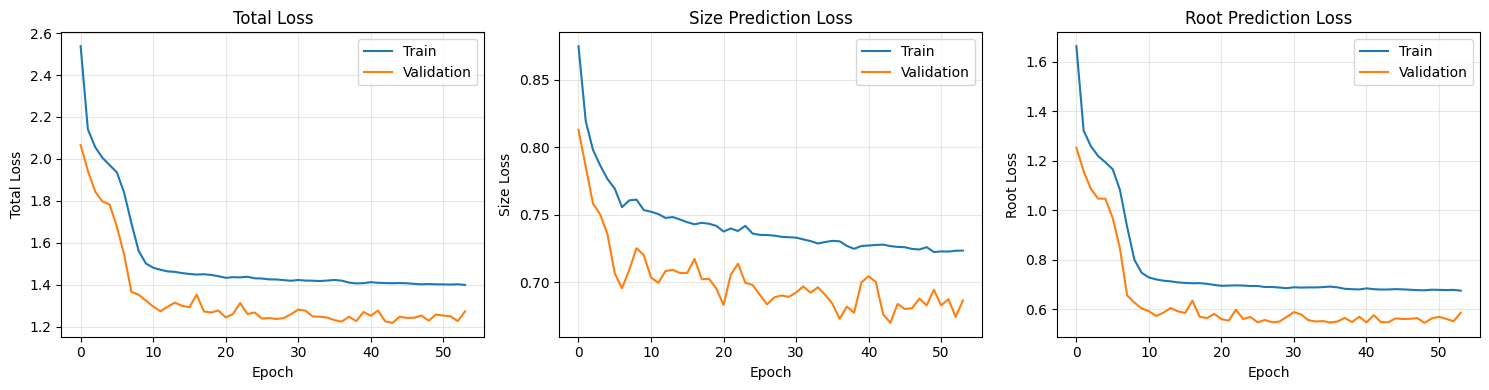

In [21]:
import matplotlib.pyplot as plt

# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total loss
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Total Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Size loss
axes[1].plot(history['train_size_loss'], label='Train')
axes[1].plot(history['val_size_loss'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Size Loss')
axes[1].set_title('Size Prediction Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Root loss
axes[2].plot(history['train_root_loss'], label='Train')
axes[2].plot(history['val_root_loss'], label='Validation')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Root Loss')
axes[2].set_title('Root Prediction Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Analyze predictions by size
from collections import defaultdict

size_analysis = defaultdict(lambda: {'correct': 0, 'total': 0})

for pred in test_predictions:
    true_size = pred['true_size']
    size_analysis[true_size]['total'] += 1
    if pred['predicted_roots'] == pred['true_roots']:
        size_analysis[true_size]['correct'] += 1

print("\nExact Match Accuracy by True RootList Size:")
print("-" * 40)
for size in sorted(size_analysis.keys()):
    data = size_analysis[size]
    acc = data['correct'] / data['total'] if data['total'] > 0 else 0
    print(f"  Size {size}: {acc*100:.1f}% ({data['correct']}/{data['total']})")


Exact Match Accuracy by True RootList Size:
----------------------------------------
  Size 1: 80.3% (15271/19018)
  Size 2: 23.9% (1226/5139)
  Size 3: 3.1% (54/1766)
  Size 5: 3.6% (53/1453)


In [24]:
# Save model
model_save_path = Path.cwd() / 'sequence_predictor_d5_query3.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'config': config,
    'history': history,
    'test_metrics': test_metrics,
}, model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to c:\Users\tomas\JavaProjects\Aibeceles\ml\graph_label_prediction\workbooks\sequence_predictor_d5_query3.pt


## Summary

This notebook implements a RootList sequence predictor with:

1. **SequenceDataLoader**: Loads wNum=0 leaf nodes with complete RootLists from Neo4j
2. **RootListTokenizer**: Converts RootList integers (-20 to +20) to/from tokens
3. **NodeEncoder**: GCN or GAT backbone for graph-aware node embeddings
4. **SequenceEncoder**: Transformer encoder over context window of 8 nodes
5. **RootListDecoder**: Autoregressive transformer decoder for generating RootList
6. **Training**: Teacher forcing with separate size and root losses
7. **Inference**: Autoregressive generation predicting size first, then roots
8. **Evaluation**: Size accuracy, exact match, set match, element accuracy

Key configuration options:
- `config.context_window_size`: Number of prior nodes (default: 8)
- `config.encoder_type`: 'gcn' or 'gat'
- All hyperparameters configurable via `SequencePredictorConfig`